In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
def analyze_hyperparameters(directory_path, plot_show=True, threshold=0.5):
    """
    Searches for a single CSV file in the given directory, performs analysis,
    generates visualizations, and saves the plots to a dedicated 'analysis_output'
    folder within that same directory.

    Args:
        directory_path (str): The path to the directory containing the CSV file.
        plot_show (bool): If True, displays the plots interactively.
        threshold (float): The value to subtract from the max accuracy to define
                         high-performing models for the summary.
    """
    # --- 1. Find the CSV file ---
    csv_files = glob.glob(os.path.join(directory_path, '*.csv'))

    if len(csv_files) == 1:
        file_path = csv_files[0]
        #print(f"Found CSV file: {file_path}")
    elif len(csv_files) == 0:
        print(f"Error: No CSV files found in '{directory_path}'.")
        return
    else:
        print(f"Error: More than one CSV file found in '{directory_path}'. Please ensure there is only one.")
        print("Found files:", csv_files)
        return

    # --- 2. Define and Create Output Directory ---
    output_dir = os.path.join(directory_path, 'analysis_output')
    os.makedirs(output_dir, exist_ok=True)
    print(f"\nOutput will be saved to: {output_dir}")

    # --- 3. Load Data ---
    try:
        df = pd.read_csv(file_path)
        #print(f"Successfully loaded data from '{file_path}'")
    except FileNotFoundError:
        # This is a fallback, though the glob check should prevent it.
        print(f"Error: The file '{file_path}' was not found.")
        return

    # --- 4. Correlation Analysis ---
    columns_to_correlate = ['gap', 'seq_num', 'hidden_size', 'num_layer', 'ACC']
    corr_matrix = df[columns_to_correlate].corr(method='spearman')

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=.5
    )
    plt.title('Spearman Correlation Matrix of Parameters and Accuracy', fontsize=16)

    corr_save_path = os.path.join(output_dir, 'correlation_matrix.png')
    plt.savefig(corr_save_path, dpi=300, bbox_inches='tight')
    #print(f"Correlation matrix saved to '{corr_save_path}'")
    if plot_show:
        plt.show()
    else:
        plt.close()

    # --- 5. Visualize Impact of Window Size (seq_num) ---
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 14))
    fig.suptitle('Impact of Window Size on Accuracy', fontsize=20)

    boxplot_props = {
        "showmeans": True,
        "meanprops": {
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": "8"
        }
    }

    # Plot 1: Overall impact
    sns.boxplot(ax=axes[0, 0], x='seq_num', y='ACC', data=df, **boxplot_props)
    axes[0, 0].set_title('Overall Distribution', fontsize=16)
    axes[0, 0].set_xlabel('Window Size', fontsize=14)
    axes[0, 0].set_ylabel('Accuracy (%)', fontsize=14)
    axes[0, 0].grid(True, axis='y')

    # Plot 2: Grouped by Gap
    sns.boxplot(ax=axes[0, 1], x='seq_num', y='ACC', hue='gap', data=df, **boxplot_props)
    axes[0, 1].set_title('Grouped by Gap', fontsize=16)
    axes[0, 1].set_xlabel('Window Size', fontsize=14)
    axes[0, 1].set_ylabel('')
    axes[0, 1].grid(True, axis='y')
    axes[0, 1].legend(title='Gap')

    # Plot 3: Grouped by Hidden Size
    sns.boxplot(ax=axes[1, 0], x='seq_num', y='ACC', hue='hidden_size', data=df, **boxplot_props)
    axes[1, 0].set_title('Grouped by Hidden Size', fontsize=16)
    axes[1, 0].set_xlabel('Window Size', fontsize=14)
    axes[1, 0].set_ylabel('Accuracy (%)', fontsize=14)
    axes[1, 0].grid(True, axis='y')
    axes[1, 0].legend(title='Hidden Size')

    # Plot 4: Grouped by Number of Layers
    sns.boxplot(ax=axes[1, 1], x='seq_num', y='ACC', hue='num_layer', data=df, **boxplot_props)
    axes[1, 1].set_title('Grouped by Number of Layers', fontsize=16)
    axes[1, 1].set_xlabel('Window Size', fontsize=14)
    axes[1, 1].set_ylabel('')
    axes[1, 1].grid(True, axis='y')
    axes[1, 1].legend(title='Num Layers')

    for ax in axes.flatten():
        ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    impact_save_path = os.path.join(output_dir, 'window_size_impact.png')
    plt.savefig(impact_save_path, dpi=300, bbox_inches='tight')
    #print(f"Window size impact plot saved to '{impact_save_path}'")
    if plot_show:
        plt.show()
    else:
        plt.close()


    # --- 6. Summary Statistics ---
    high_accuracy_threshold = df.ACC.max() - threshold
    num_high_performers = df.loc[df.ACC > high_accuracy_threshold].shape[0]
    print(f"{num_high_performers} models reached accuracy over {high_accuracy_threshold:.2f}%. Highest Accuracy Recorded: {df.ACC.max():.4f}%")

    print(df.loc[df.ACC > high_accuracy_threshold])



def analyze_hyper_transformer(directory_path, plot_show=True, threshold=0.5):
    """
    Searches for a single hyperparameter results CSV file in the given directory,
    performs analysis tailored for the Transformer model, generates visualizations,
    and saves the plots to a dedicated 'analysis_output' folder.

    Args:
        directory_path (str): The path to the directory containing the CSV file.
        plot_show (bool): If True, displays the plots interactively.
        threshold (float): The value to subtract from the max accuracy to define
                           high-performing models for the summary.
    """
    # --- 1. Find the CSV file ---
    csv_files = glob.glob(os.path.join(directory_path, '*.csv'))

    if len(csv_files) == 1:
        file_path = csv_files[0]
    elif len(csv_files) == 0:
        print(f"Error: No CSV files found in '{directory_path}'.")
        return
    else:
        print(f"Error: More than one CSV file found in '{directory_path}'. Please ensure there is only one.")
        print("Found files:", csv_files)
        return

    # --- 2. Define and Create Output Directory ---
    output_dir = os.path.join(directory_path, 'analysis_output')
    os.makedirs(output_dir, exist_ok=True)
    print(f"\nAnalysis output will be saved to: {output_dir}")

    # --- 3. Load Data ---
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return
    
    # Drop the 'dropout' column if it exists to clean the data
    if 'dropout' in df.columns:
        df.drop('dropout', axis=1, inplace=True)
    if 'weight_decay' in df.columns:
        df.drop('weight_decay', axis=1, inplace=True)
    if 'learning_rate' in df.columns:
        df.drop('learning_rate', axis=1, inplace=True)

    # --- 4. Correlation Analysis ---
    # ✅ CHANGED: Updated columns for Transformer hyperparameters
    columns_to_correlate = ['seq_num','d_model', 'n_head', 'num_layer', 'ACC']
    
    # Ensure all columns exist before trying to correlate
    valid_columns = [col for col in columns_to_correlate if col in df.columns]
    corr_matrix = df[valid_columns].corr(method='spearman')

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=.5
    )
    plt.title('Spearman Correlation Matrix of Transformer Parameters and Accuracy', fontsize=16)

    corr_save_path = os.path.join(output_dir, 'correlation_matrix.png')
    plt.savefig(corr_save_path, dpi=300, bbox_inches='tight')
    if plot_show:
        plt.show()
    else:
        plt.close()

    # --- 5. Visualize Impact of Window Size (seq_num) ---
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 14))
    fig.suptitle('Impact of Key Hyperparameters on Accuracy', fontsize=20)

    boxplot_props = {
        "showmeans": True,
        "meanprops": {
            "marker": "o", "markerfacecolor": "white",
            "markeredgecolor": "black", "markersize": "8"
        }
    }

    # Plot 1: Overall impact of window size
    sns.boxplot(ax=axes[0, 0], x='num_layer', y='ACC', data=df, **boxplot_props)
    axes[0, 0].set_title('Impact of Number of Number of Layers', fontsize=16)
    axes[0, 0].set_xlabel('Number of Layers', fontsize=14)
    axes[0, 0].set_ylabel('Accuracy (%)', fontsize=14)
    axes[0, 0].grid(True, axis='y')

    # Plot 2: Grouped by Model Dimension (d_model)
    # ✅ CHANGED: Replaced 'hidden_size' with 'd_model'
    sns.boxplot(ax=axes[0, 1], x='num_layer', y='ACC', hue='d_model', data=df, **boxplot_props)
    axes[0, 1].set_title('Grouped by Model Dimension (d_model)', fontsize=16)
    axes[0, 1].set_xlabel('Number of Layers', fontsize=14)
    axes[0, 1].set_ylabel('')
    axes[0, 1].grid(True, axis='y')
    axes[0, 1].legend(title='d_model')

    # Plot 3: Grouped by Number of Attention Heads (n_head)
    # ✅ CHANGED: Replaced 'hidden_size' plot with 'n_head' plot
    sns.boxplot(ax=axes[1, 0], x='num_layer', y='ACC', hue='n_head', data=df, **boxplot_props)
    axes[1, 0].set_title('Grouped by Attention Heads (n_head)', fontsize=16)
    axes[1, 0].set_xlabel('Number of Layers', fontsize=14)
    axes[1, 0].set_ylabel('Accuracy (%)', fontsize=14)
    axes[1, 0].grid(True, axis='y')
    axes[1, 0].legend(title='n_head')

    # Plot 4: Grouped by Number of Attention Heads (n_head)
    # ✅ CHANGED: Replaced 'hidden_size' plot with 'seq_num' plot
    sns.boxplot(ax=axes[1, 1], x='num_layer', y='ACC', hue='seq_num', data=df, **boxplot_props)
    axes[1, 1].set_title('Grouped by Window Size', fontsize=16)
    axes[1, 1].set_xlabel('Number of Layers', fontsize=14)
    axes[1, 1].set_ylabel('Accuracy (%)', fontsize=14)
    axes[1, 1].grid(True, axis='y')
    axes[1, 1].legend(title='Window Size')
    for ax in axes.flatten():
        ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    impact_save_path = os.path.join(output_dir, 'hyperparameter_impact.png')
    plt.savefig(impact_save_path, dpi=300, bbox_inches='tight')
    if plot_show:
        plt.show()
    else:
        plt.close()


    # --- 6. Summary Statistics ---
    if not df.empty and 'ACC' in df.columns:
        max_acc = df.ACC.max()
        high_accuracy_threshold = max_acc - threshold
        high_performers_df = df.loc[df.ACC >= high_accuracy_threshold].sort_values(by='ACC', ascending=False)
        
        print("\n" + "="*50)
        print("HYPERPARAMETER ANALYSIS SUMMARY")
        print("="*50)
        print(f"Highest Accuracy Recorded: {max_acc:.4f}%")
        print(f"\nDisplaying {len(high_performers_df)} models with accuracy >= {high_accuracy_threshold:.2f}%:")
        print(high_performers_df.to_string())
    else:
        print("\nCould not generate summary statistics. DataFrame might be empty or missing 'ACC' column.")




# Source Robot: Franka_main


Output will be saved to: trained_models/franka_main/m2_cnnBiLSTM_contactDetection/64/analysis_output


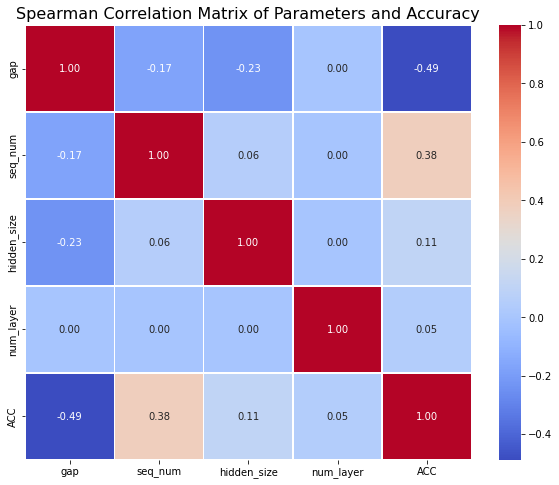

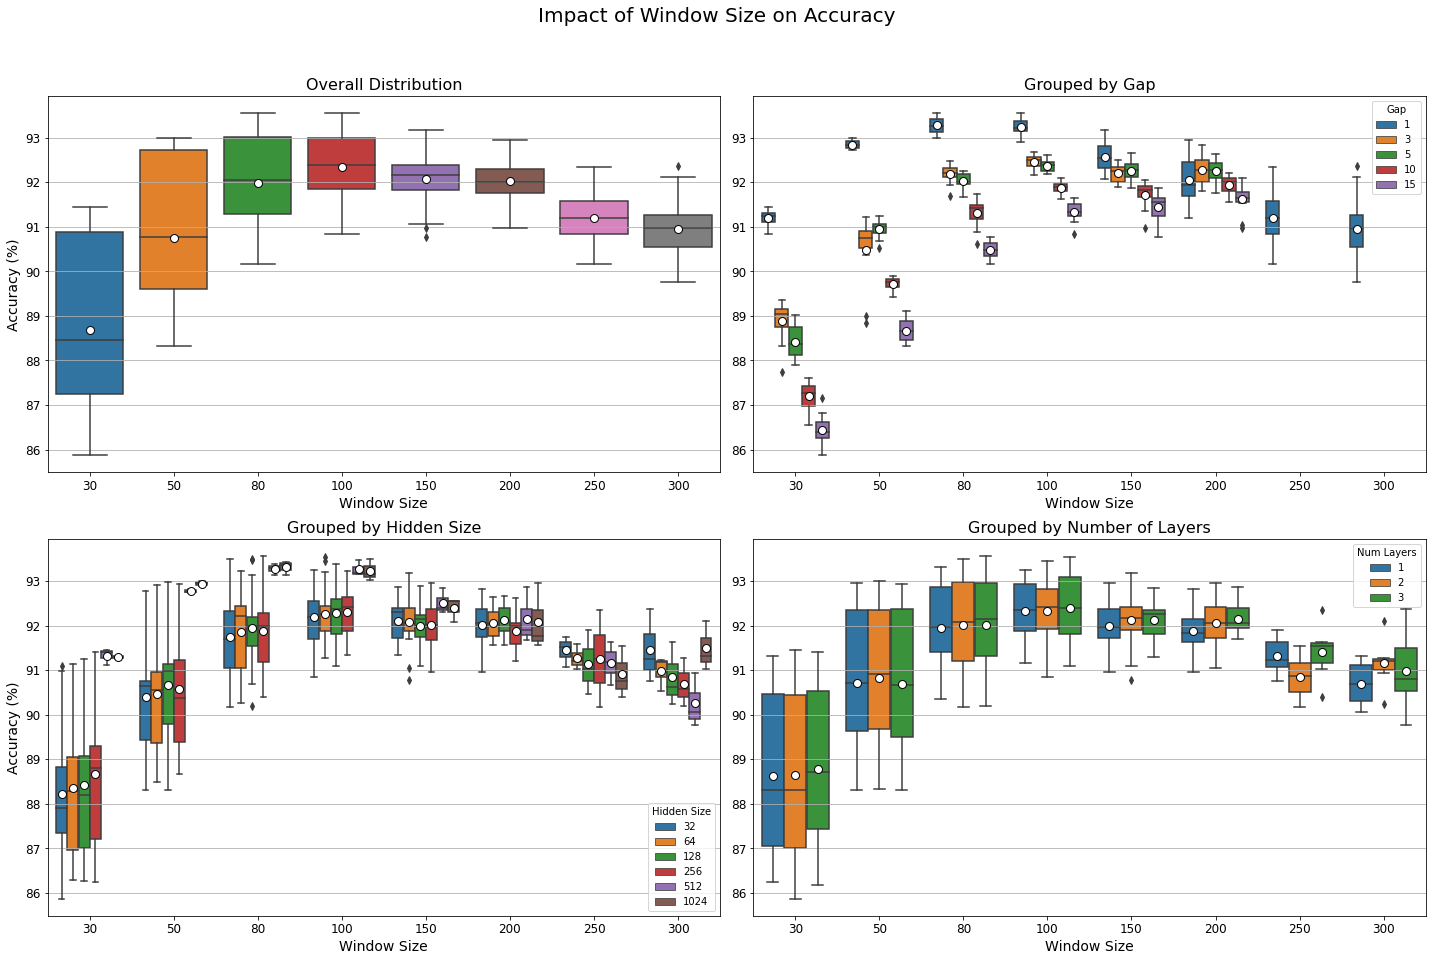

12 models reached accuracy over 93.35%. Highest Accuracy Recorded: 93.5544%
     gap  seq_num  hidden_size  num_layer        ACC  train_size  val_size
325    1       80           32          2  93.502703     1083137    104505
331    1       80          128          2  93.486436     1083137    104505
332    1       80          128          3  93.472083     1083137    104505
335    1       80          256          3  93.554375     1083137    104505
337    1       80          512          2  93.390747     1083137    104505
340    1       80         1024          2  93.363954     1083137    104505
341    1       80         1024          3  93.433807     1083137    104505
346    1      100           64          2  93.452747     1073117    102501
347    1      100           64          3  93.542502     1073117    102501
350    1      100          128          3  93.386406     1073117    102501
356    1      100          512          3  93.473234     1073117    102501
359    1      100       

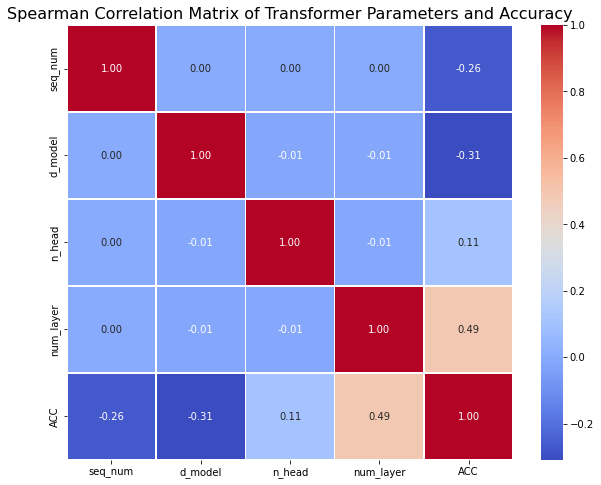

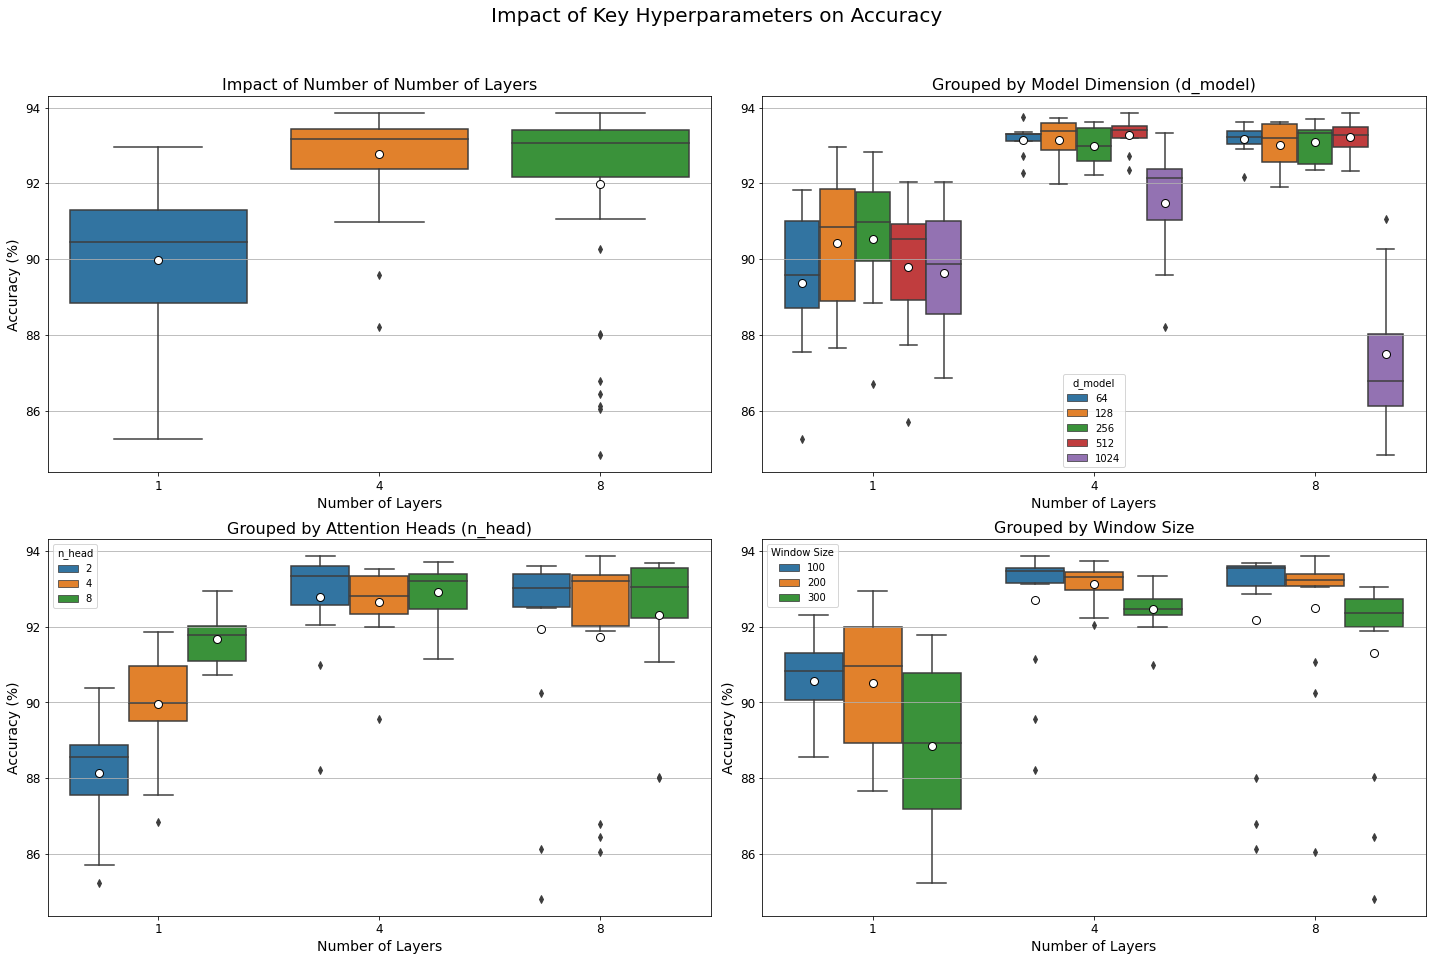


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 93.8560%

Displaying 6 models with accuracy >= 93.66%:
    seq_num  d_model  n_head  num_layer        ACC
76      200      512       4          8  93.856035
28      100      512       2          4  93.855947
45      200       64       2          4  93.743580
60      200      128       8          4  93.711141
26      100      256       8          8  93.686647
35      100      512       8          8  93.671985


In [6]:
#analyze_hyperparameters(directory_path='trained_models/franka_main/m1_cnnBiLSTM_contactDetection', plot_show= False, threshold=0.05)
analyze_hyperparameters(directory_path='trained_models/franka_main/m2_cnnBiLSTM_contactDetection/64', plot_show= True, threshold=0.2)
analyze_hyper_transformer(directory_path='trained_models/franka_main/m2_transformer_contactDetection/64', plot_show= True, threshold=0.2)


Output will be saved to: trained_models/franka_main/m2_cnnBiLSTM_contactLocalization/64/analysis_output


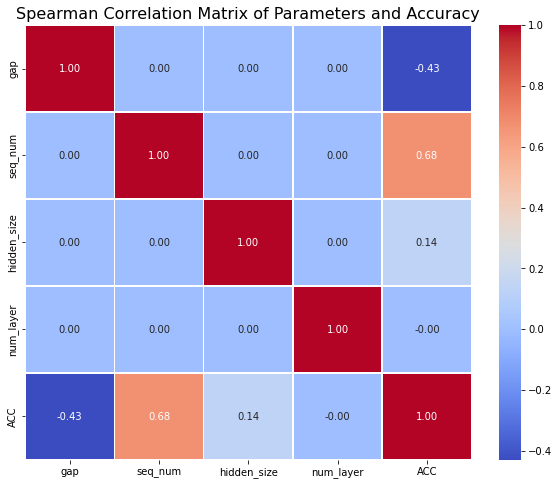

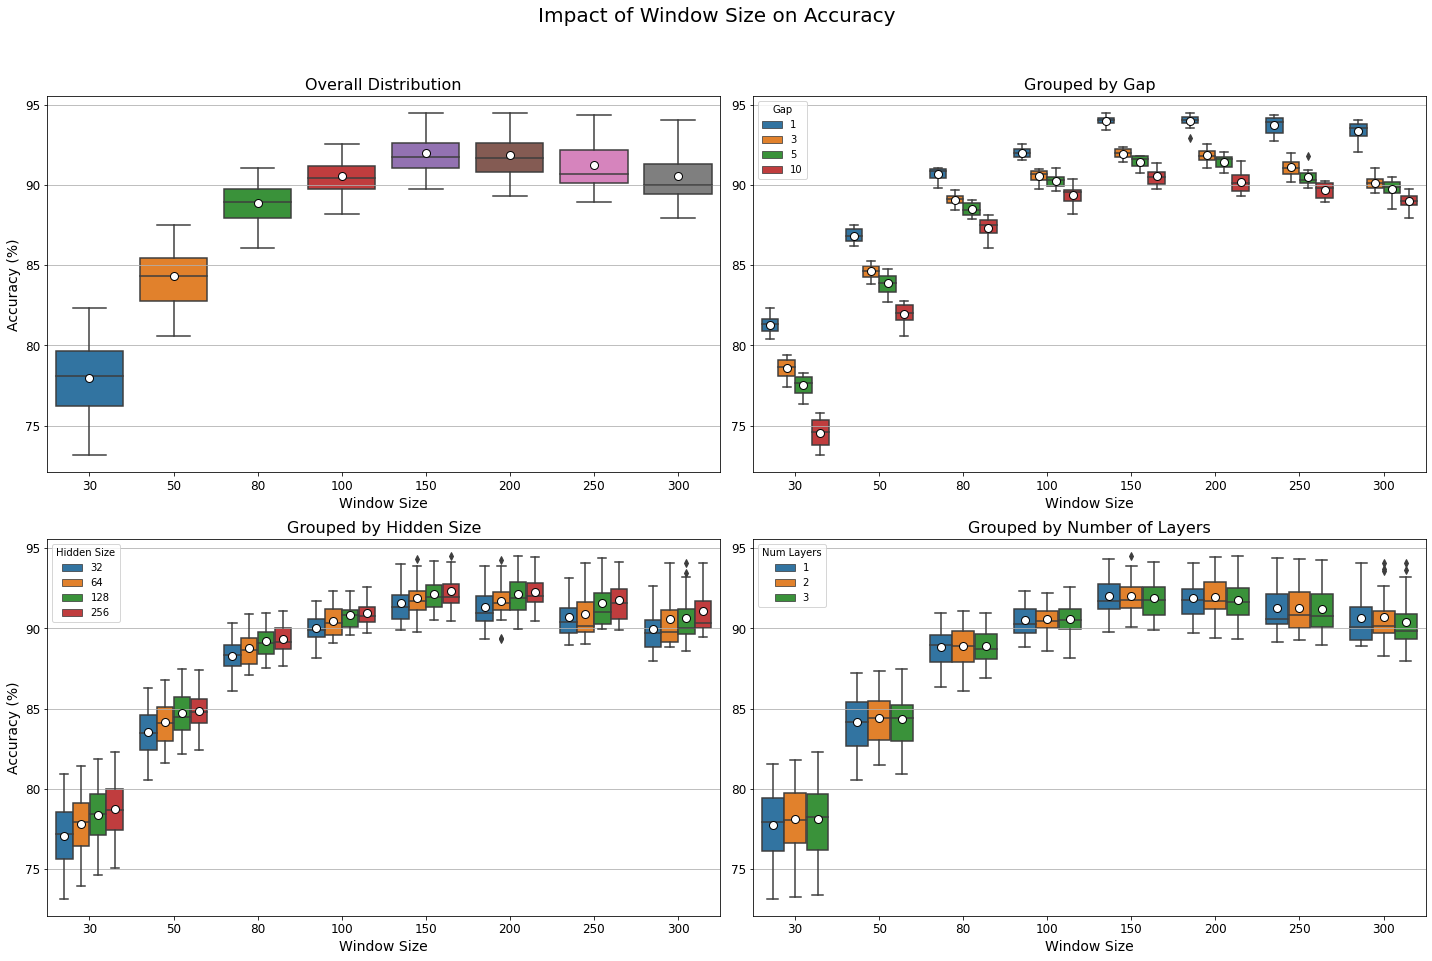

6 models reached accuracy over 94.29%. Highest Accuracy Recorded: 94.4918%
    seq_num  gap  hidden_size  num_layer        ACC  train_size  val_size
51      150    1           64          1  94.326603      497463     41157
58      150    1          256          2  94.491824      497463     41157
68      200    1          128          3  94.488828      497194     38177
70      200    1          256          2  94.425963      497194     38177
78      250    1          128          1  94.383709      496312     35308
79      250    1          128          2  94.321400      496312     35308

Analysis output will be saved to: trained_models/franka_main/m2_transformer_contactLocalization/64/analysis_output


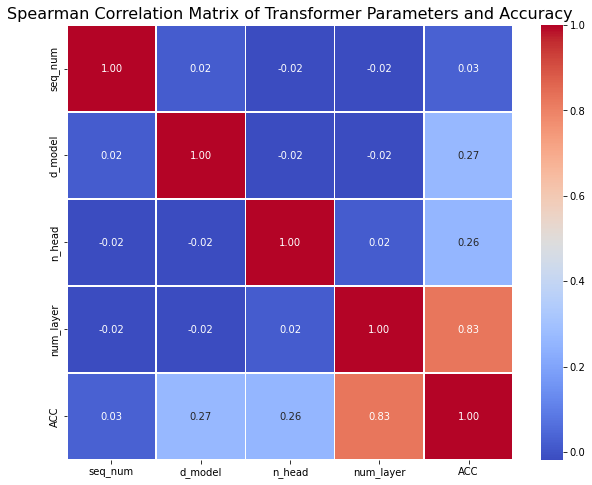

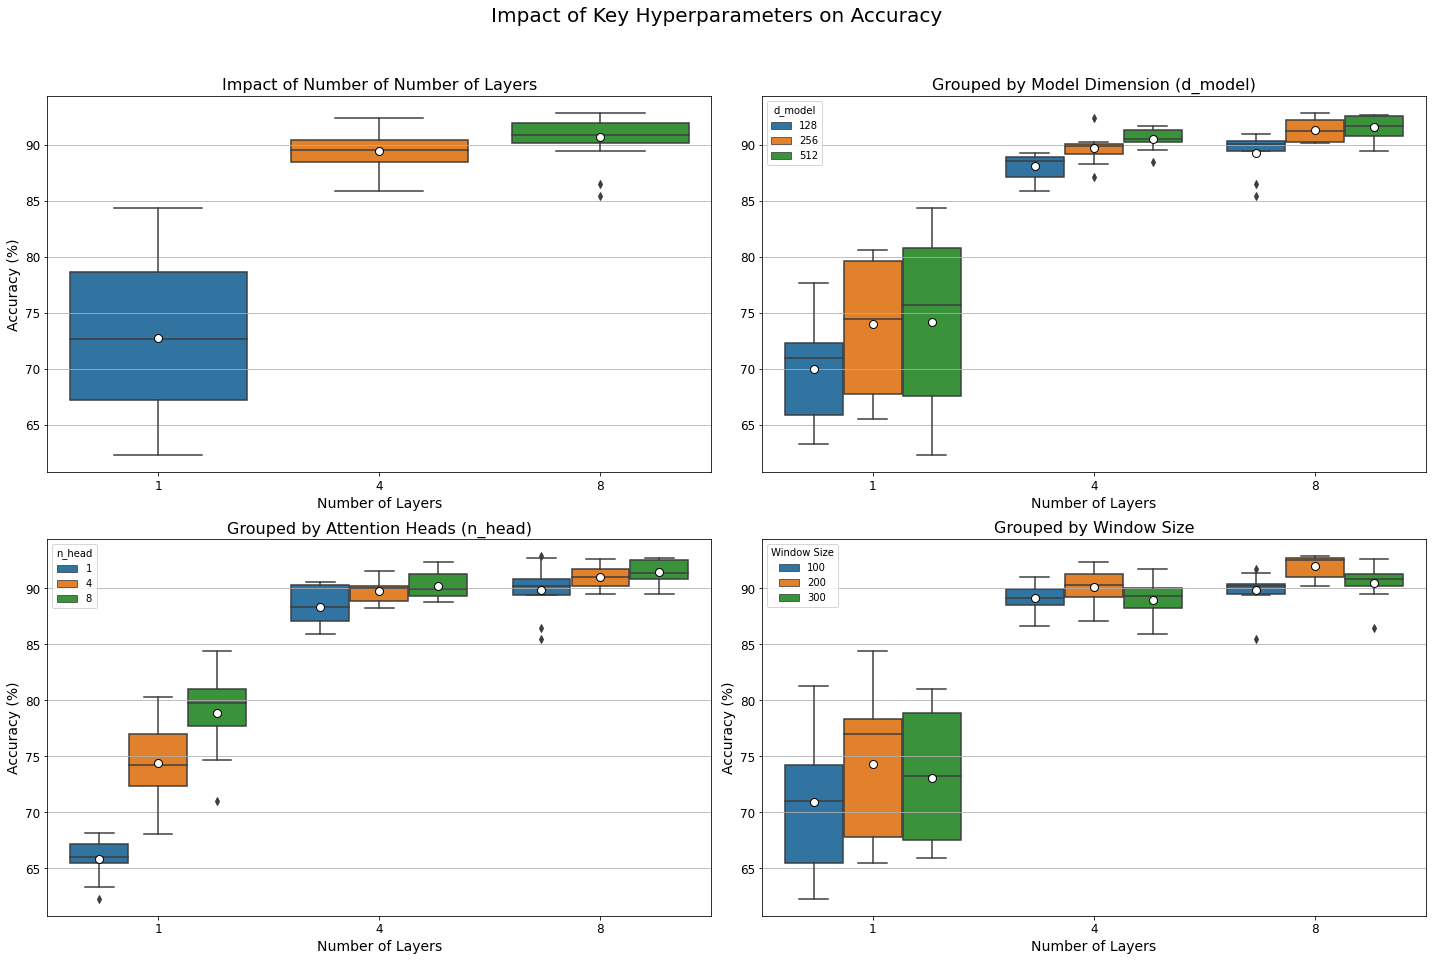


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 92.8648%

Displaying 6 models with accuracy >= 92.56%:
    seq_num  gap  d_model  n_head  num_layer        ACC  train_size  val_size
38      200    1      256       1          8  92.864814     1023017     92481
53      200    1      512       8          8  92.718129     1023017     92481
47      200    1      512       1          8  92.710271     1023017     92481
50      200    1      512       4          8  92.629070     1023017     92481
81      300    1      512       8          8  92.604650      972917     82461
44      200    1      256       8          8  92.581921     1023017     92481


In [3]:
#analyze_hyperparameters(directory_path='trained_models/franka_main/m1_cnnBiLSTM_contactLocalization', plot_show= False, threshold=0.08)
analyze_hyperparameters(directory_path='trained_models/franka_main/m2_cnnBiLSTM_contactLocalization/64', plot_show= True, threshold=0.2)
analyze_hyper_transformer(directory_path='trained_models/franka_main/m2_transformer_contactLocalization/64', plot_show= True, threshold=0.3)

# Target Robot: Franka_Mindlab


Output will be saved to: trained_models/franka_mindlab/m2_cnnBiLSTM_contactDetection/64/analysis_output


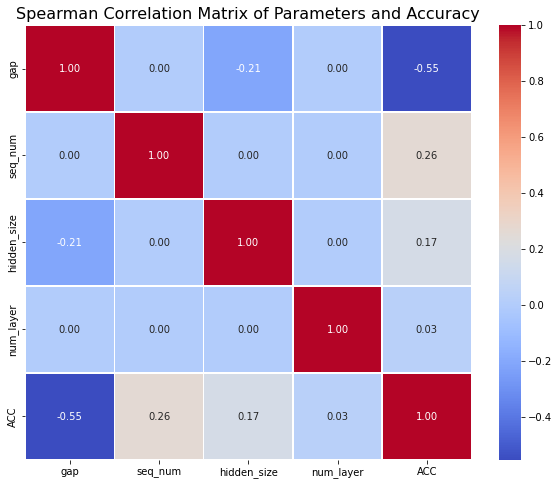

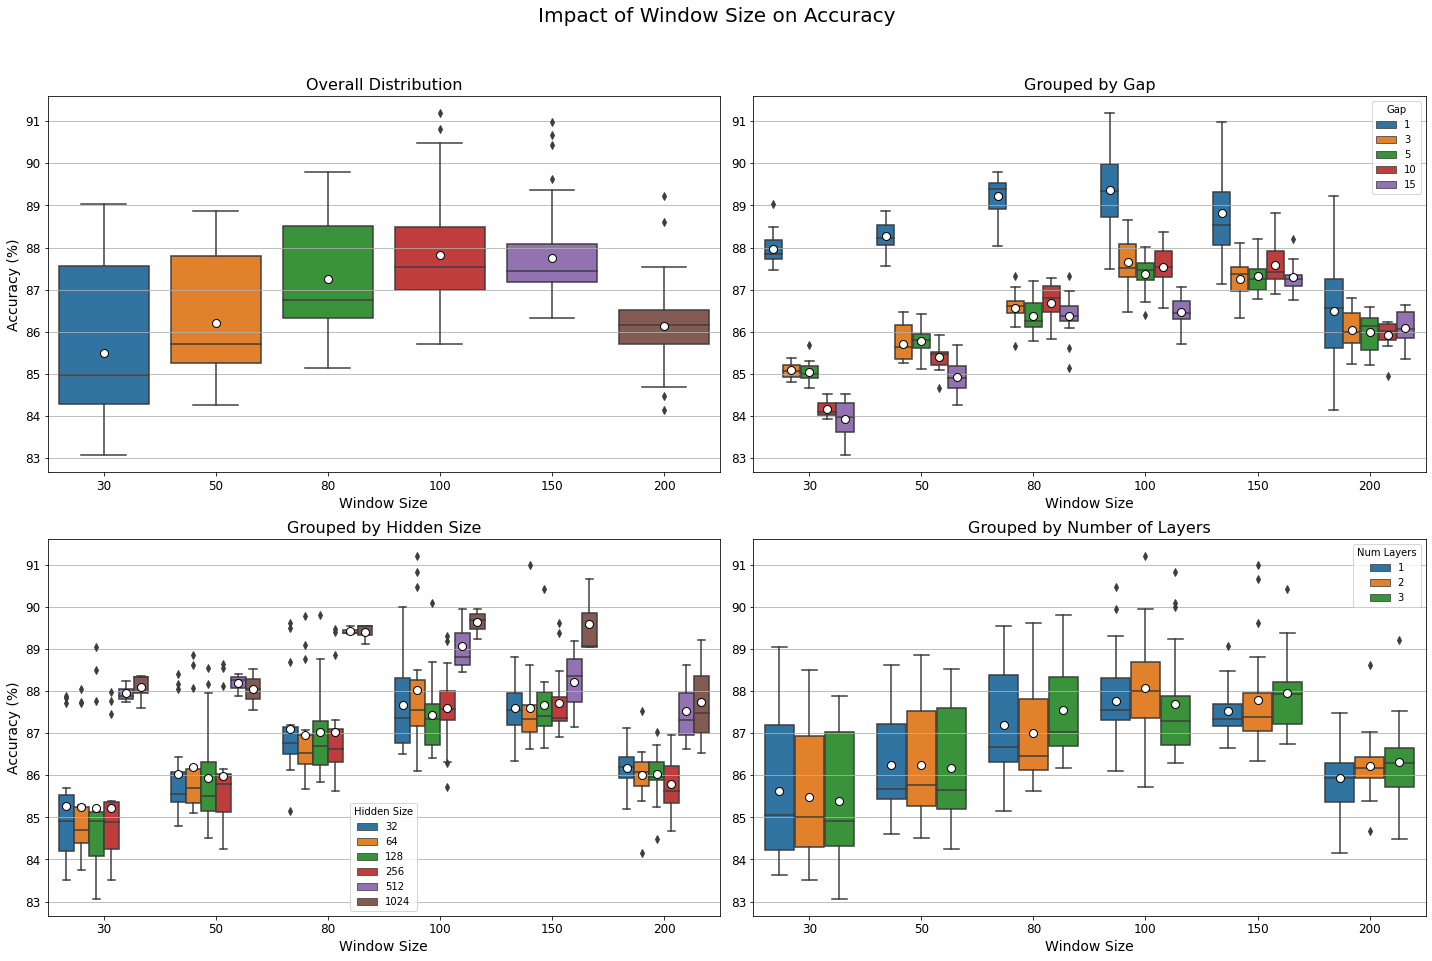

1 models reached accuracy over 90.99%. Highest Accuracy Recorded: 91.1945%
    gap  seq_num  hidden_size  num_layer        ACC  train_size  val_size
58    1      100           64          2  91.194501       55850      5383

Analysis output will be saved to: trained_models/franka_mindlab/m2_transformer_contactDetection/64/analysis_output


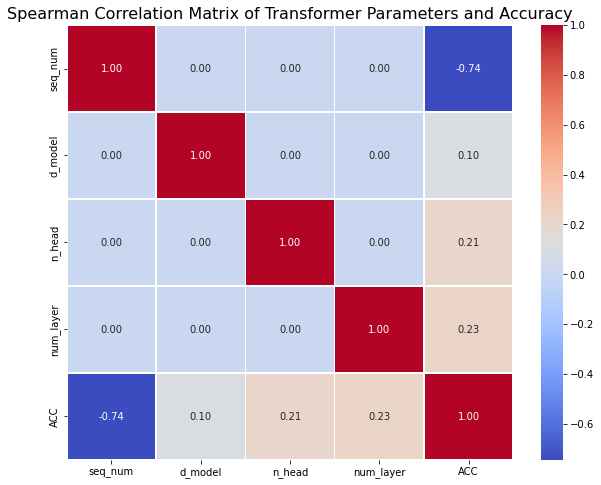

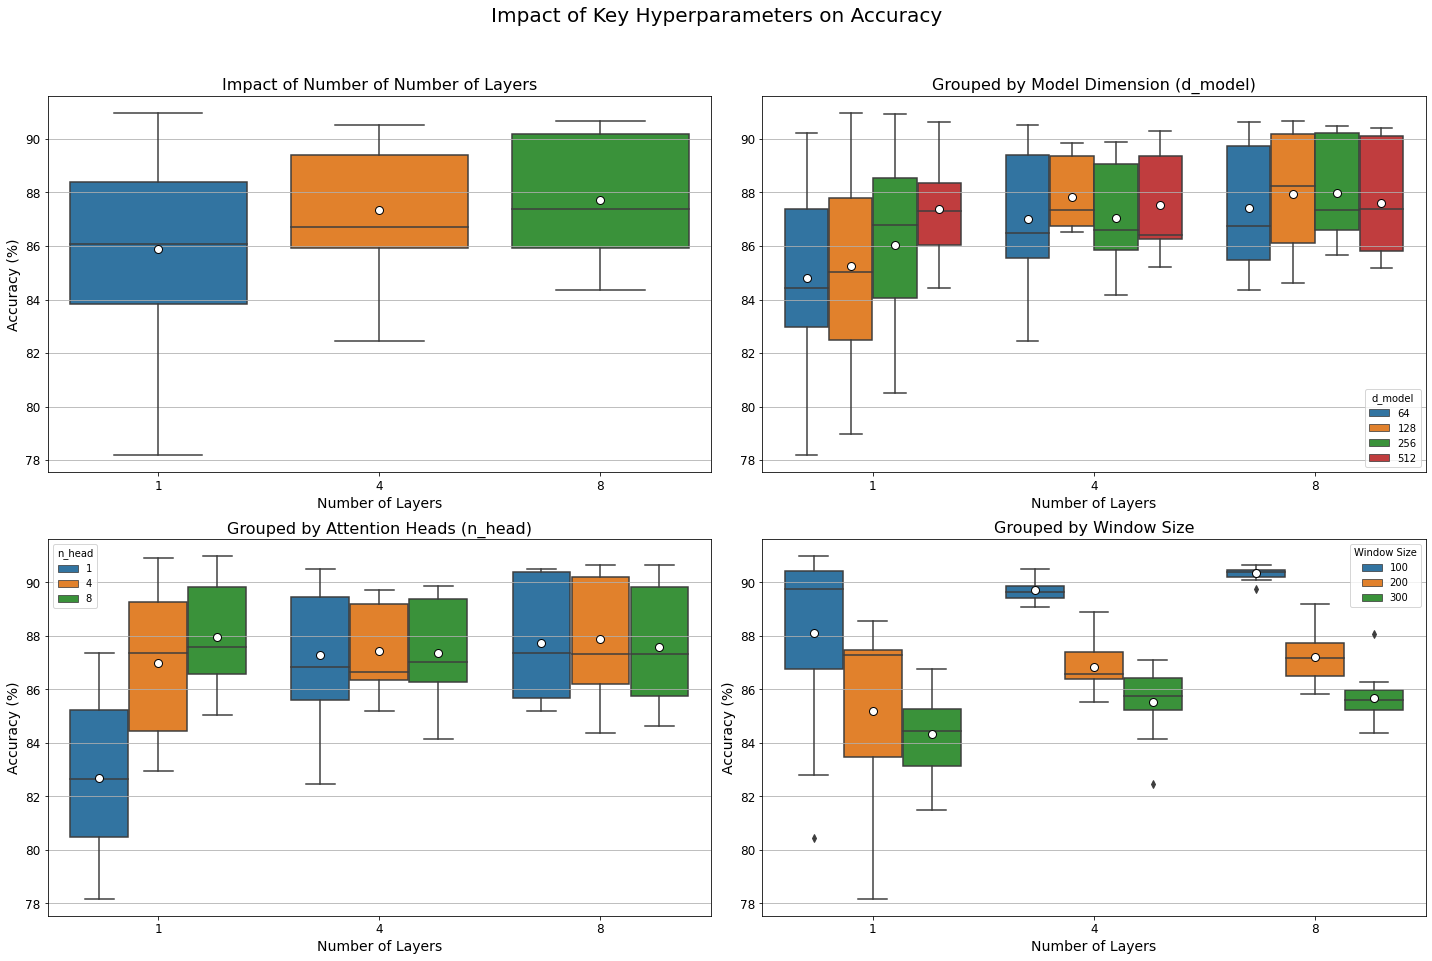


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 90.9716%

Displaying 2 models with accuracy >= 90.77%:
    seq_num  d_model  n_head  num_layer        ACC
15      100      128       8          1  90.971577
21      100      256       4          1  90.915846


In [4]:
#analyze_hyperparameters(directory_path='trained_models/franka_mindlab/m1_cnnBiLSTM_contactDetection/64', plot_show= False, threshold=0.02)
analyze_hyperparameters(directory_path='trained_models/franka_mindlab/m2_cnnBiLSTM_contactDetection/64', plot_show= True, threshold=0.2)
analyze_hyper_transformer(directory_path='trained_models/franka_mindlab/m2_transformer_contactDetection/64', plot_show= True, threshold=0.2)



Output will be saved to: trained_models/franka_mindlab/m2_cnnBiLSTM_contactLocalization/64/analysis_output


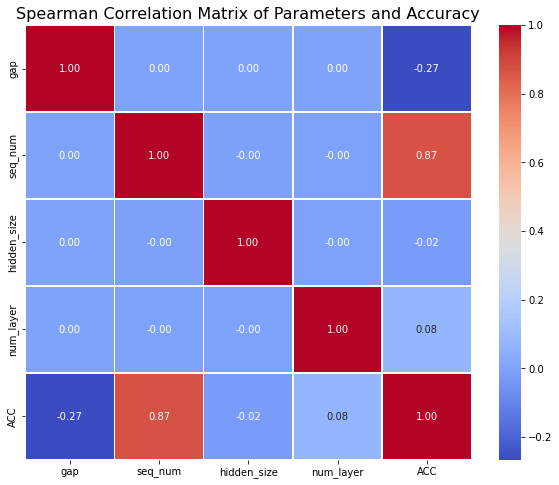

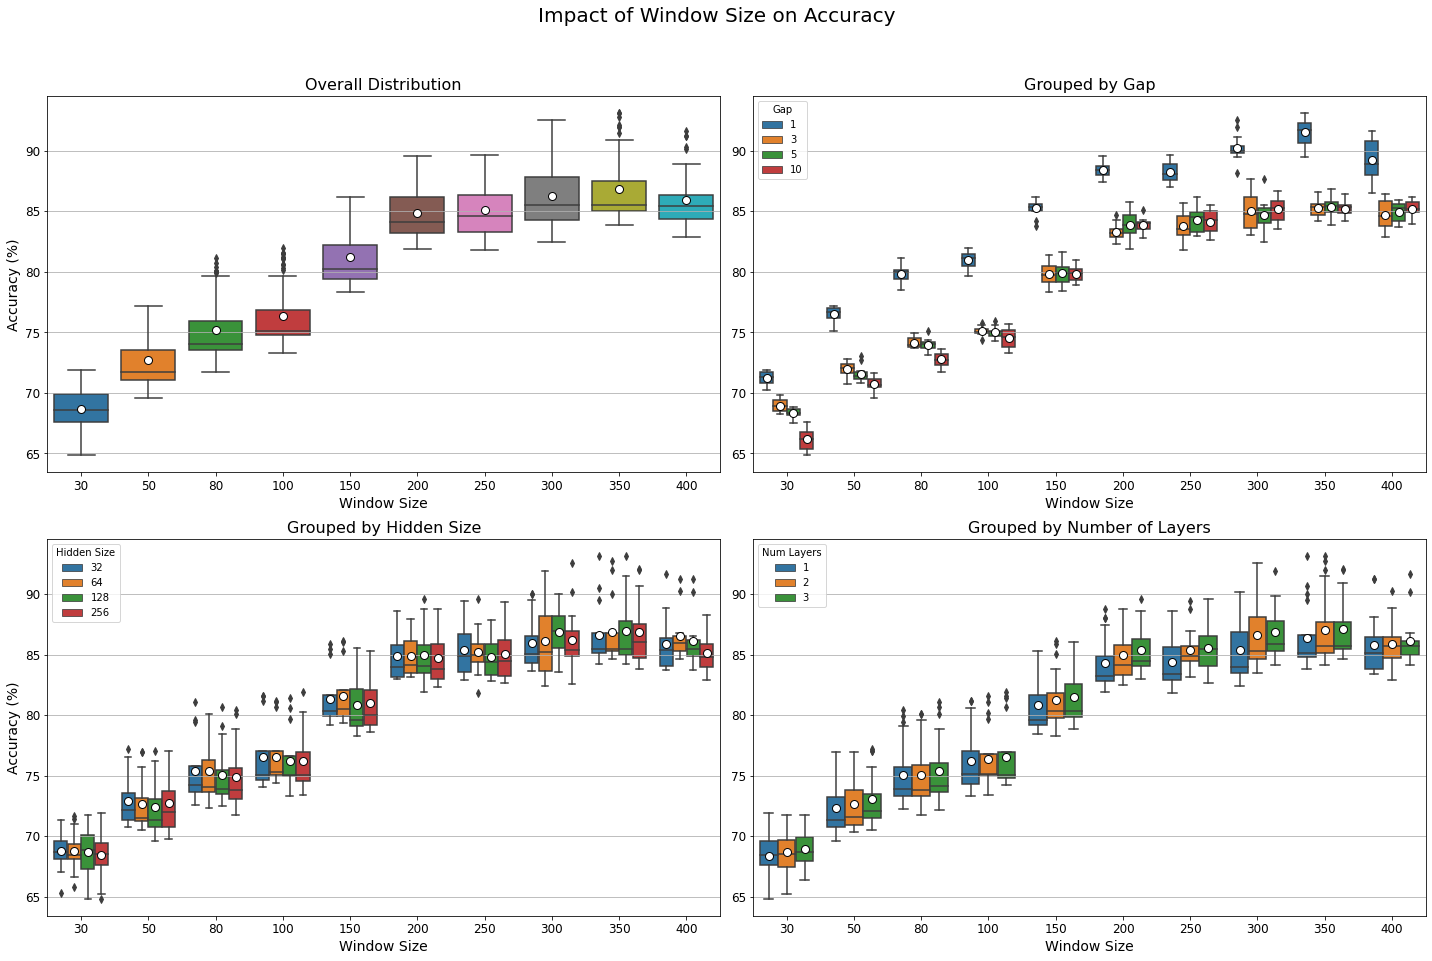

2 models reached accuracy over 93.02%. Highest Accuracy Recorded: 93.1034%
     seq_num  gap  hidden_size  num_layer        ACC  train_size  val_size
97       350    1           32          2  93.103448       20606      1160
102      350    1          128          1  93.103448       20606      1160

Analysis output will be saved to: trained_models/franka_mindlab/m2_transformer_contactLocalization/64/analysis_output


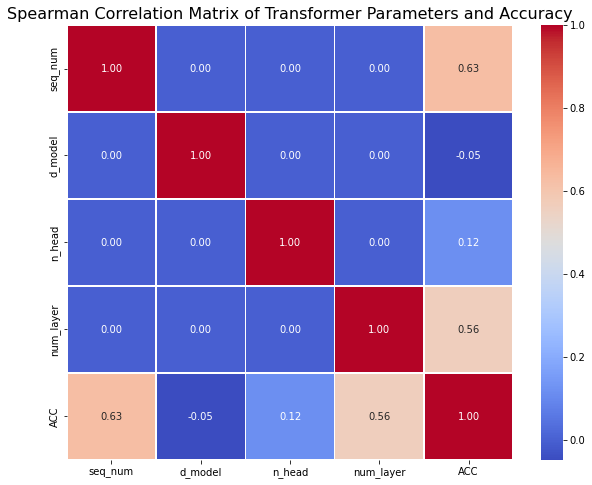

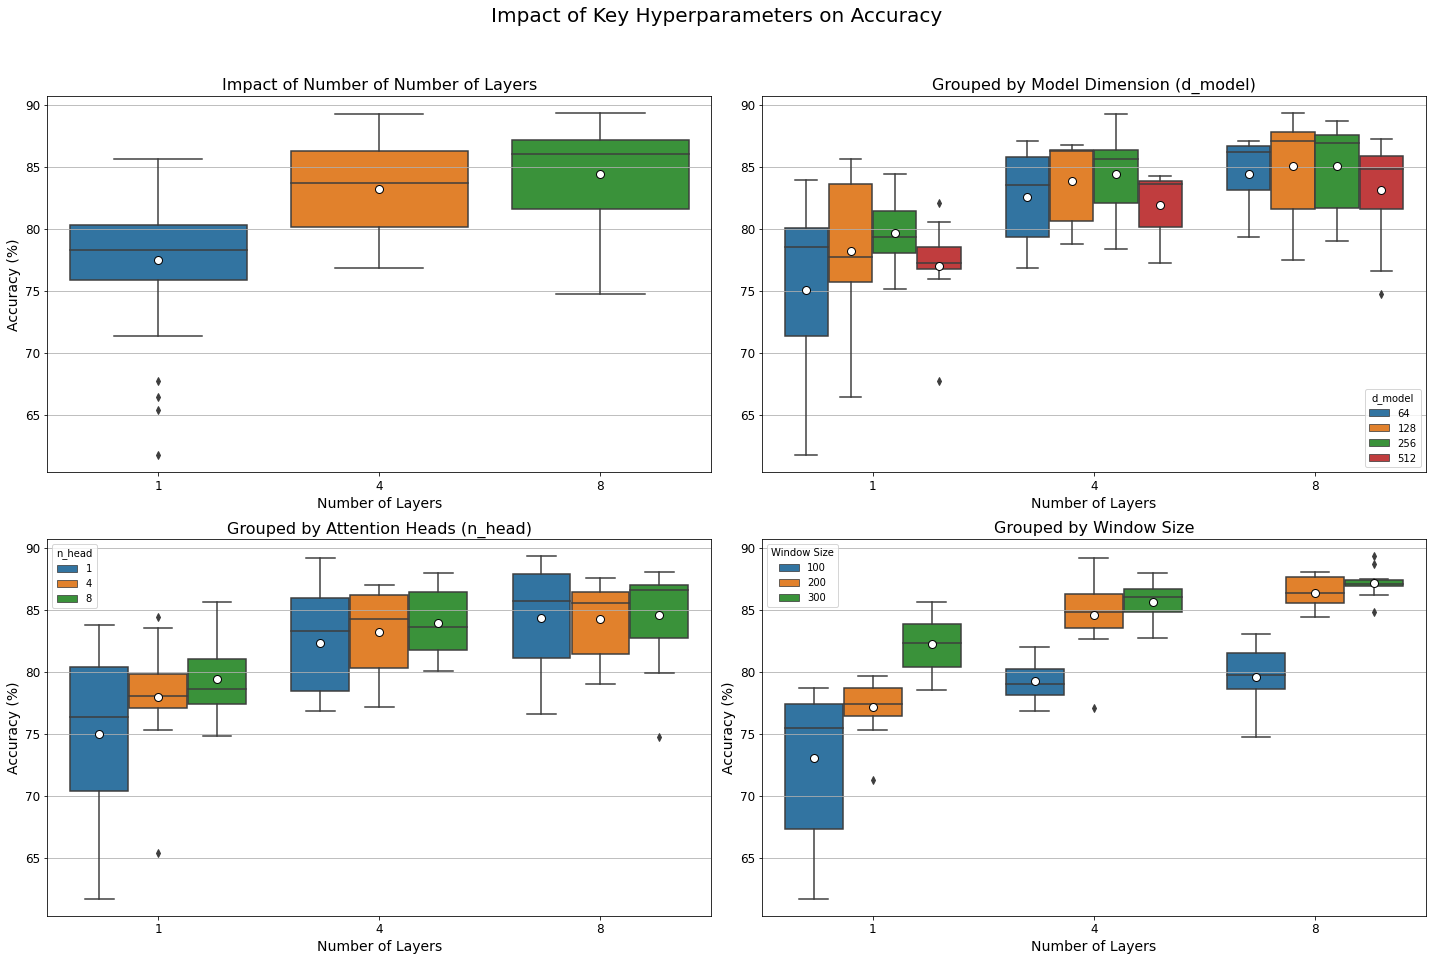


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 89.3429%

Displaying 2 models with accuracy >= 89.14%:
    seq_num  gap  d_model  n_head  num_layer        ACC  train_size  val_size
83      300    1      128       1          8  89.342949       51650      4543
55      200    1      256       1          4  89.236111       53750      4963


In [7]:
#analyze_hyperparameters(directory_path='trained_models/franka_mindlab/m1_cnnBiLSTM_contactLocalization/64', plot_show= False, threshold=0.03)
analyze_hyperparameters(directory_path='trained_models/franka_mindlab/m2_cnnBiLSTM_contactLocalization/64', plot_show= True, threshold=0.08)
analyze_hyper_transformer(directory_path='trained_models/franka_mindlab/m2_transformer_contactLocalization/64', plot_show= True, threshold=0.2)


# Target Robot: UR5


Output will be saved to: trained_models/ur5/m2_cnnBiLSTM_contactDetection/64/analysis_output


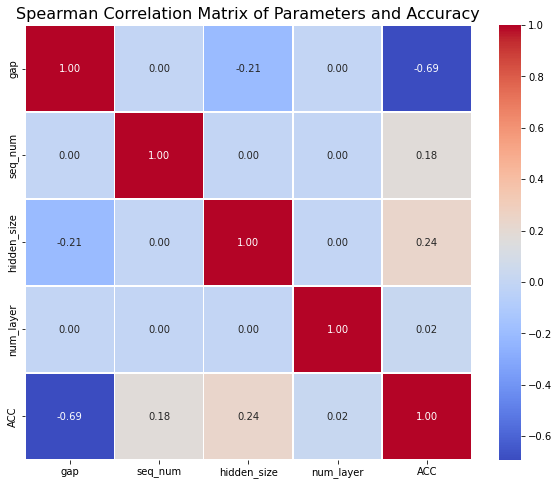

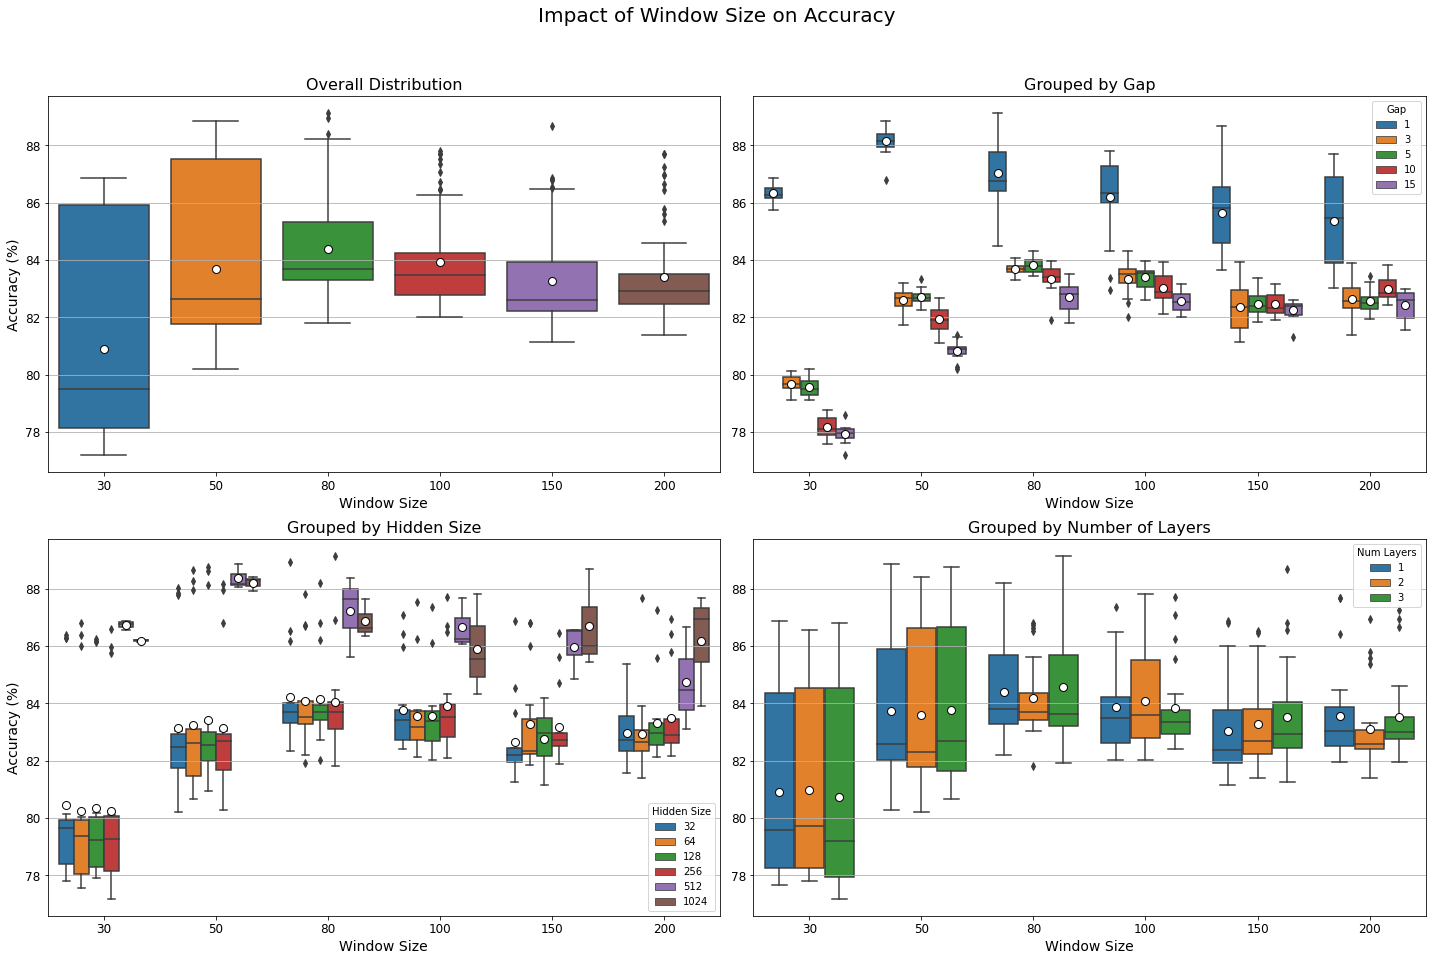

1 models reached accuracy over 89.06%. Highest Accuracy Recorded: 89.1353%
     gap  seq_num  hidden_size  num_layer        ACC  train_size  val_size
335    1       80          256          3  89.135255       64499      6314

Analysis output will be saved to: trained_models/ur5/m2_transformer_contactDetection/64/analysis_output


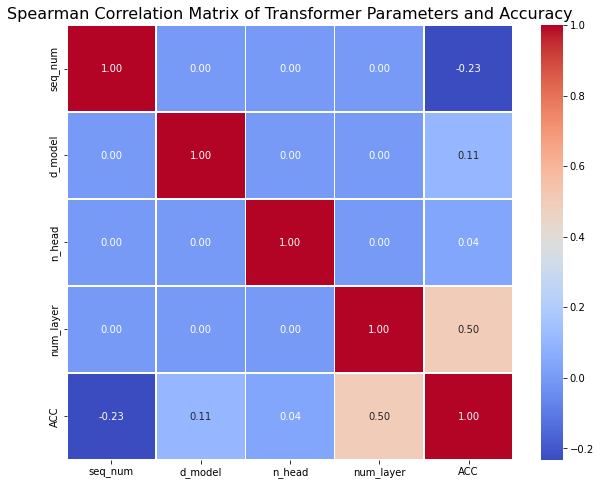

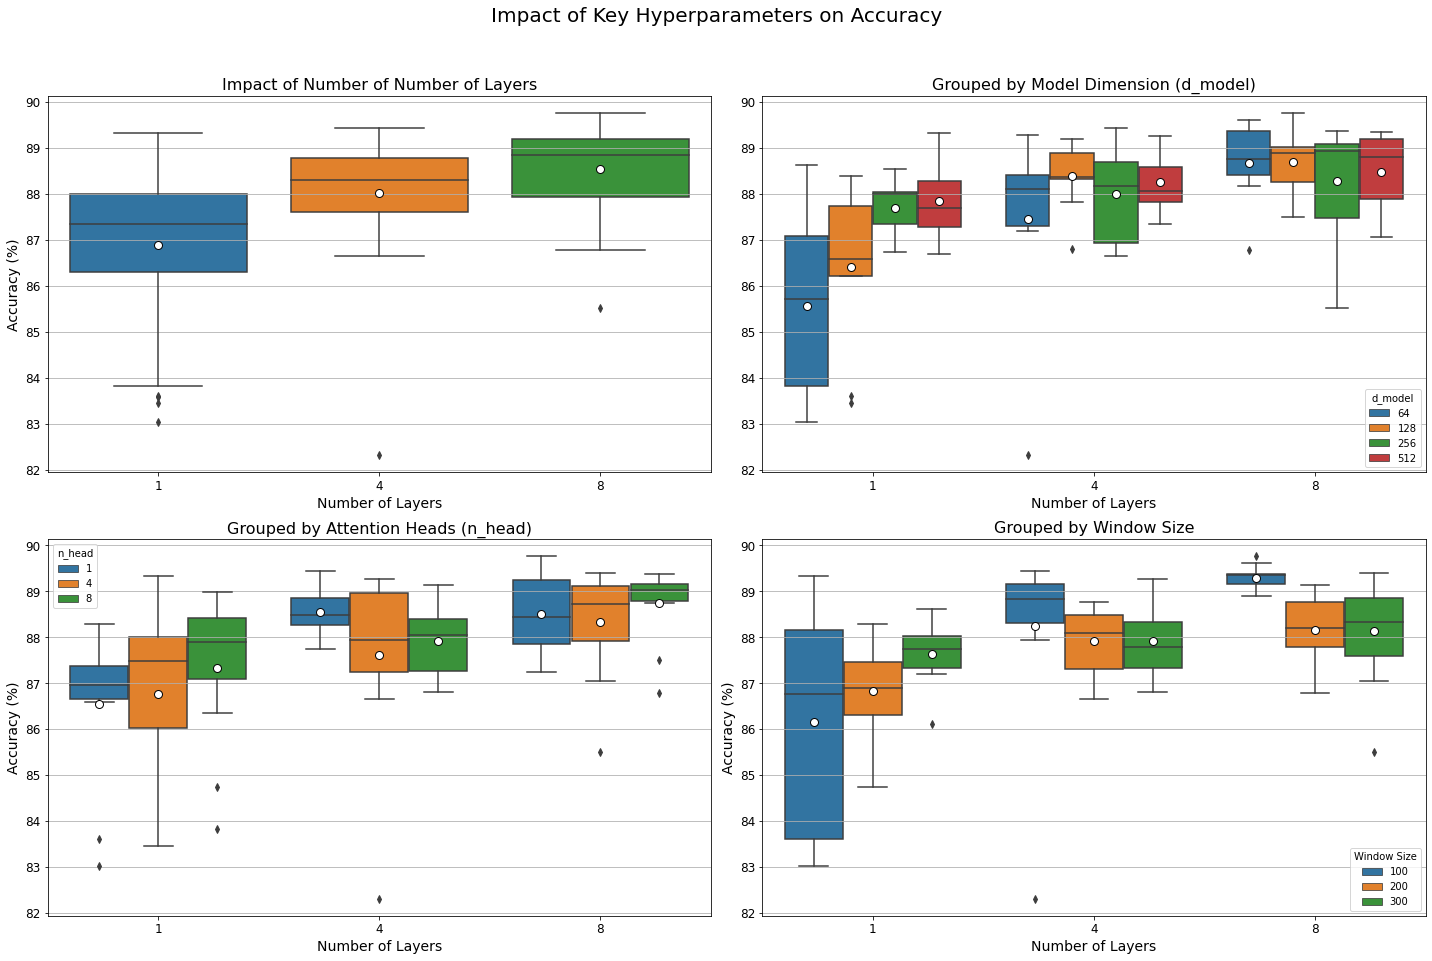


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 89.7629%

Displaying 2 models with accuracy >= 89.56%:
    seq_num  d_model  n_head  num_layer        ACC
11      100      128       1          8  89.762897
2       100       64       1          8  89.618712


In [5]:
#analyze_hyperparameters(directory_path='trained_models/ur5/m1_cnnBiLSTM_contactDetection/64', plot_show= True, threshold=0.2)
analyze_hyperparameters(directory_path='trained_models/ur5/m2_cnnBiLSTM_contactDetection/64/', plot_show= True, threshold=0.08)
analyze_hyper_transformer(directory_path='trained_models/ur5/m2_transformer_contactDetection/64', plot_show= True, threshold=0.2)



Output will be saved to: trained_models/ur5/m2_cnnBiLSTM_contactLocalization/64/analysis_output


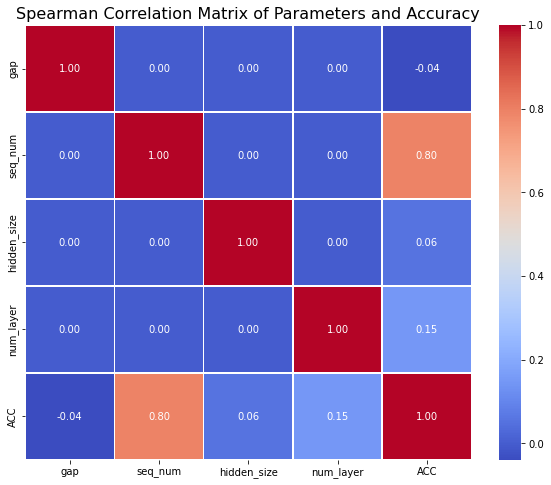

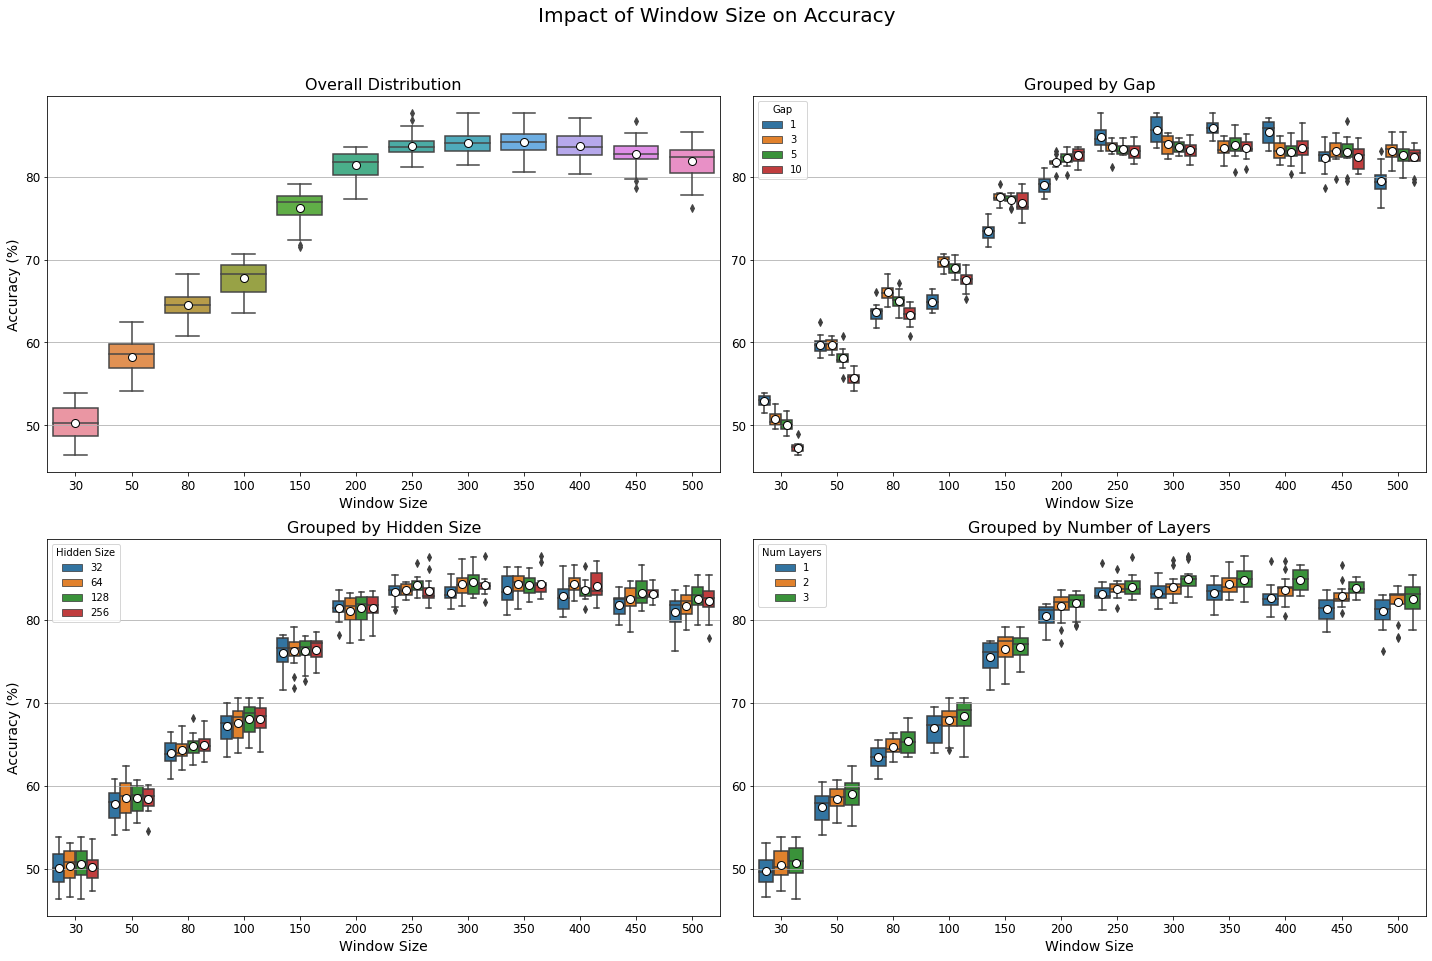

5 models reached accuracy over 87.27%. Highest Accuracy Recorded: 87.6712%
     seq_num  gap  hidden_size  num_layer        ACC  train_size  val_size
515      250    1          256          3  87.643021       18390       874
521      300    1           64          3  87.297634       18390       803
524      300    1          128          3  87.546700       18390       803
527      300    1          256          3  87.671233       18390       803
539      350    1          256          3  87.652646       18390       737

Analysis output will be saved to: trained_models/ur5/m2_transformer_contactLocalization/64/analysis_output


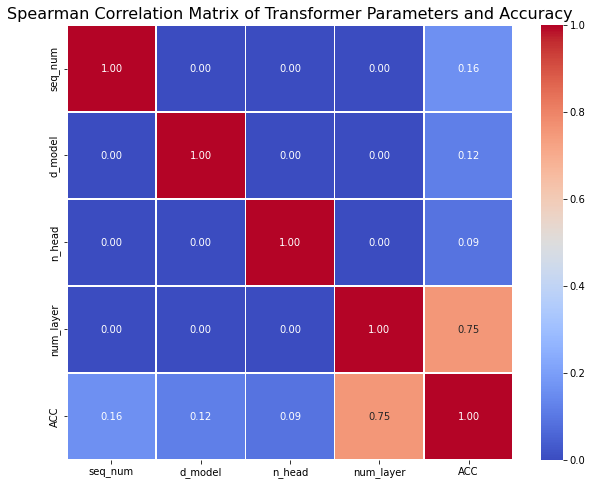

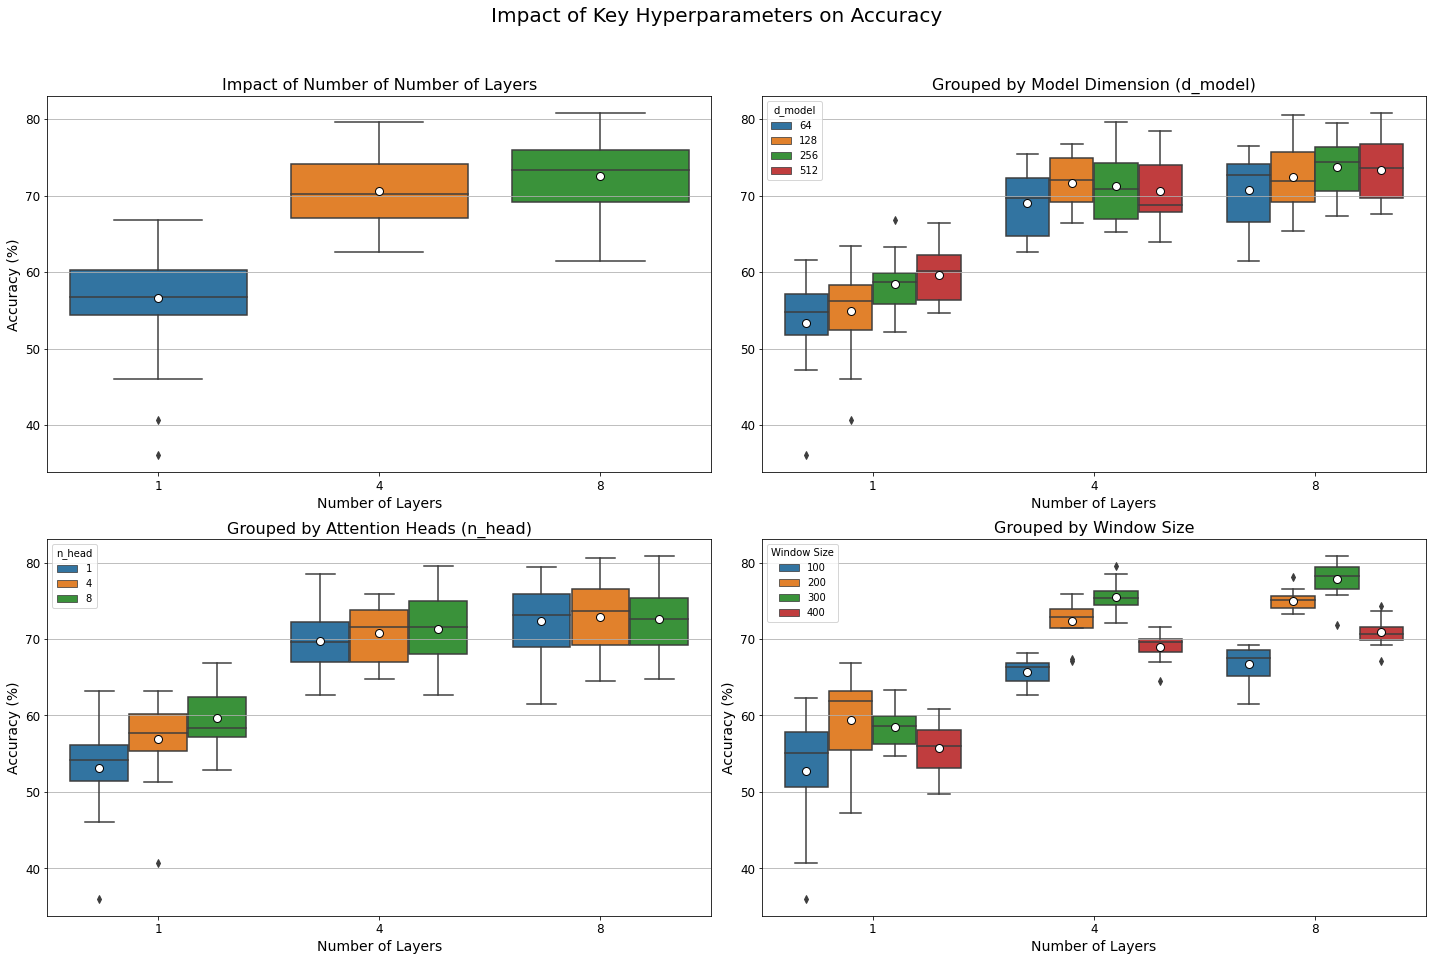


HYPERPARAMETER ANALYSIS SUMMARY
Highest Accuracy Recorded: 80.8219%

Displaying 1 models with accuracy >= 80.62%:
     seq_num  gap  d_model  n_head  num_layer        ACC  train_size  val_size
107      300    1      512       8          8  80.821918       60585      5556


In [3]:
#analyze_hyperparameters(directory_path='trained_models/ur5/m1_cnnBiLSTM_contactLocalization/64', plot_show= True, threshold=0.04)
analyze_hyperparameters(directory_path='trained_models/ur5/m2_cnnBiLSTM_contactLocalization/64', plot_show= True, threshold=0.4)
analyze_hyper_transformer(directory_path='trained_models/ur5/m2_transformer_contactLocalization/64', plot_show= True, threshold=0.2)


# Paper Result

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

def analyze_hyperparameters(data_path, save_path, plot_show=True, threshold=0.5):
    """
    Analyzes hyperparameter tuning results from a CSV file for either a CNN-BiLSTM
    or a Transformer model. It generates and saves a model-specific box plot,
    a Spearman correlation matrix, and prints a summary of high-performing models.

    Args:
        data_path (str): The full path to the input CSV file.
        save_path (str): The path to the directory where plots will be saved.
        plot_show (bool): If True, displays the plots interactively.
        threshold (float): The accuracy value to subtract from the max accuracy to
                           define high-performing models.
    """
    # --- 1. Load Data and Prepare Paths ---
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        print(f"Error: The file '{data_path}' was not found.")
        return

    os.makedirs(save_path, exist_ok=True)
    
    data_path_split = data_path.split('/')
    end_idx = len(data_path_split)-1
    mode_name = f'{data_path_split[end_idx-3]}_{data_path_split[end_idx-2]}'
    file_prefix = os.path.join(save_path, f'{mode_name}')

    # Define common properties for box plots
    boxplot_props = {
        "showmeans": True,
        "meanprops": {
            "marker": "o", "markerfacecolor": "white",
            "markeredgecolor": "black", "markersize": "8"
        }
    }

    # --- 2. Model-Specific Preprocessing and Plotting ---
    
    # Use lowercase check for robustness
    if 'cnn' in data_path.lower():
        rename_dict = {
            'seq_num': 'Window Length',
            'gap': 'Gap',
            'hidden_size': 'Hidden Size',
            'num_layer': 'LSTM Layers'
        }
        df.rename(columns=rename_dict, inplace=True)
        columns_to_correlate = ['Window Length', 'Gap', 'Hidden Size', 'LSTM Layers', 'ACC']
        
        # PLOTTING BLOCK: Create, configure, and save the plot here
        plt.figure(figsize=(12, 8))
        ax = sns.boxplot(x='Window Length', y='ACC', hue='Gap', data=df, **boxplot_props)
        ax.set_title('Impact of Window Length on Accuracy, Grouped by Gap', fontsize=16)
        ax.set_xlabel('Window Length', fontsize=14)
        ax.set_ylabel('Accuracy (%)', fontsize=14)
        ax.grid(True, axis='y')
        ax.legend(title='Gap')
        
        plot_save_path = f'{file_prefix}_WindowLength_vs_Gap.png'
        plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
        #print(f"Box plot saved to: {plot_save_path}")

    elif 'transformer' in data_path.lower():
        #print(f"\n--- Analyzing Transformer Model: {file_prefix} ---")
        # Drop columns and filter rows first
        df.drop(columns=['dropout', 'weight_decay', 'learning_rate'], inplace=True, errors='ignore')
        df.drop(df[df.d_model > 512].index, inplace=True) # remove d_models=1024
        
        rename_dict = {
            'seq_num': 'Window Length',
            'n_head': 'Num. Heads',
            'num_layer': 'Encoder Layers',
            'd_model': 'd_model'
        }
        df.rename(columns=rename_dict, inplace=True)
        
        columns_to_correlate = ['Encoder Layers', 'Window Length',  'd_model', 'Num. Heads', 'ACC']

        # PLOTTING BLOCK: Create, configure, and save the plot here
        plt.figure(figsize=(12, 8))
        ax = sns.boxplot(x='Encoder Layers', y='ACC', hue='Window Length', data=df, **boxplot_props)
        ax.set_title('Impact of Encoder Layers on Accuracy, Grouped by Window Length', fontsize=16)
        ax.set_xlabel('Encoder Layers', fontsize=14)
        ax.set_ylabel('Accuracy (%)', fontsize=14)
        ax.grid(True, axis='y')
        ax.legend(title='Window Length')
        
        plot_save_path = f'{file_prefix}_EncoderLayers_vs_WindowLength.png'
        plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
        # print(f"Box plot saved to: {plot_save_path}")

    else:
        print(f"Error: Could not determine model type from path '{data_path}'. Expected 'cnn' or 'transformer'.")
        return

    if plot_show:
        plt.show()
    else:
        plt.close()

    # --- 3. Correlation Analysis (Common for all models) ---
    corr_matrix = df[columns_to_correlate].corr(method='spearman')

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=.5
    )
    plt.title('Spearman Correlation Matrix of Parameters and Accuracy', fontsize=16)
    
    corr_save_path = f'{file_prefix}_correlation_matrix.png'
    plt.savefig(corr_save_path, dpi=300, bbox_inches='tight')

    if plot_show:
        plt.show()
    else:
        plt.close()

    # --- 4. Summary Statistics (Common for all models) ---
    if not df.empty and 'ACC' in df.columns:
        max_acc = df['ACC'].max()
        high_accuracy_threshold = max_acc - threshold
        high_performers_df = df.loc[df['ACC'] >= high_accuracy_threshold].sort_values(by='ACC', ascending=False)
        
        print(f"Highest Accuracy Recorded: {max_acc:.4f}%")
        #print(f"\nDisplaying {len(high_performers_df)} models with accuracy >= {high_accuracy_threshold:.2f}%:")
        # Displaying with original column names for clarity if they exist
    else:
        print("\nCould not generate summary statistics. DataFrame is empty or missing 'ACC' column.")

In [3]:
SEARCH_DIRECTORY = 'trained_models/' 
ANALYSIS_OUTPUT_DIRECTORY = '.analysis_output_64/'
print(f"🔍 Searching for folders containing '64' inside '{SEARCH_DIRECTORY}'...")
search_pattern = os.path.join(SEARCH_DIRECTORY, '**', '64', '*.csv')
csv_files_to_process = glob.glob(search_pattern, recursive=True)

if not csv_files_to_process:
    print(f"❌ No 'results.csv' files found inside folders containing '64'.")
    print(f"Please check the path '{SEARCH_DIRECTORY}' and your folder structure.")
else:
    print(f"✅ Found {len(csv_files_to_process)} result file(s) to analyze.")
    
    # Loop through each found file and call the analysis function
    for file_path in csv_files_to_process:
        print(file_path)
        if 'm1' in file_path: 
            threshold = .01 
        else: 
            threshold = .02

        analyze_hyperparameters(
            data_path=file_path, 
            save_path=ANALYSIS_OUTPUT_DIRECTORY,
            plot_show=False,  # Set to False to avoid opening many plot windows
            threshold= threshold     # Analyze models within 1.0% of the max accuracy
        )
        
    print(f"\n🎉 Analysis complete. All plots saved to '{ANALYSIS_OUTPUT_DIRECTORY}'.")


🔍 Searching for folders containing '64' inside 'trained_models/'...
✅ Found 18 result file(s) to analyze.
trained_models/franka_main/m1_cnnBiLSTM_contactLocalization/64/hyperparameter_results_localization.csv
Highest Accuracy Recorded: 98.7460%
trained_models/franka_main/m2_cnnBiLSTM_contactDetection/64/hyperparameter_results.csv
Highest Accuracy Recorded: 93.1727%
trained_models/franka_main/m1_cnnBiLSTM_contactDetection/64/hyperparameter_results.csv
Highest Accuracy Recorded: 95.9478%
trained_models/franka_main/m2_transformer_contactLocalization/64/hyperparameter_results_localization.csv
Highest Accuracy Recorded: 92.8648%
trained_models/franka_main/m2_transformer_contactDetection/64/hyperparameter_results_expanded.csv
Highest Accuracy Recorded: 93.8560%
trained_models/franka_main/m2_cnnBiLSTM_contactLocalization/64/hyperparameter_results_localization.csv
Highest Accuracy Recorded: 92.5495%
trained_models/franka_mindlab/m1_cnnBiLSTM_contactLocalization/64/hyperparameter_results_locali

In [39]:
SEARCH_DIRECTORY = 'trained_models/' 
ANALYSIS_OUTPUT_DIRECTORY = '.analysis_output_64/'
print(f"🔍 Searching for folders containing '64' inside '{SEARCH_DIRECTORY}'...")
search_pattern = os.path.join(SEARCH_DIRECTORY, '**', '64', '*.csv')
csv_files_to_process = glob.glob(search_pattern, recursive=True)
csv_files_to_process

🔍 Searching for folders containing '64' inside 'trained_models/'...


['trained_models/franka_main/m1_cnnBiLSTM_contactLocalization/64/hyperparameter_results_localization.csv',
 'trained_models/franka_main/m2_cnnBiLSTM_contactDetection/64/hyperparameter_results.csv',
 'trained_models/franka_main/m1_cnnBiLSTM_contactDetection/64/hyperparameter_results.csv',
 'trained_models/franka_main/m2_transformer_contactLocalization/64/hyperparameter_results_localization.csv',
 'trained_models/franka_main/m2_transformer_contactDetection/64/hyperparameter_results_expanded.csv',
 'trained_models/franka_main/m2_cnnBiLSTM_contactLocalization/64/hyperparameter_results_localization.csv',
 'trained_models/franka_mindlab/m1_cnnBiLSTM_contactLocalization/64/hyperparameter_results_localization.csv',
 'trained_models/franka_mindlab/m2_cnnBiLSTM_contactDetection/64/hyperparameter_results.csv',
 'trained_models/franka_mindlab/m1_cnnBiLSTM_contactDetection/64/hyperparameter_results.csv',
 'trained_models/franka_mindlab/m2_transformer_contactLocalization/64/hyperparameter_results_lo